# 05 — MDP: Decisiones Estacionales con Value Iteration

Este notebook demuestra el módulo `src/mdp/`.

**Técnica:** Proceso de Decisión de Markov (MDP) resuelto con **Value Iteration**.

### Espacio de estados
| Variable | Valores |
|---|---|
| Salud del cultivo | 0=Malo, 1=Regular, 2=Bueno |
| Presupuesto | 0=Bajo, 1=Medio, 2=Alto |
| Temporada | 0=Seca, 1=Lluvia |
| Riesgo de roya | 0=Bajo, 1=Alto |

**Total: 3×3×2×2 = 36 estados**

### Acciones
`fertilizar`, `fungicida`, `podar`, `cosechar_temprano`, `replantar`

### Objetivo
Encontrar la política π(s) que **maximiza la recompensa acumulada esperada** (factor de descuento γ = 0.9).

In [4]:
%pip install jinja2 --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from src.mdp.farm_mdp import todos_los_estados, recompensa, transicion, ACCIONES
from src.mdp.value_iteration import value_iteration, extract_policy, get_action_recommendation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Total de estados: {len(todos_los_estados())}")
print(f"Acciones: {ACCIONES}")

Total de estados: 36
Acciones: ['fertilizar', 'fungicida', 'podar', 'cosechar_temprano', 'replantar']


## 1. Ejecutar Value Iteration y curva de convergencia

Convergencia en 202 iteraciones — delta final = 9.54e-07


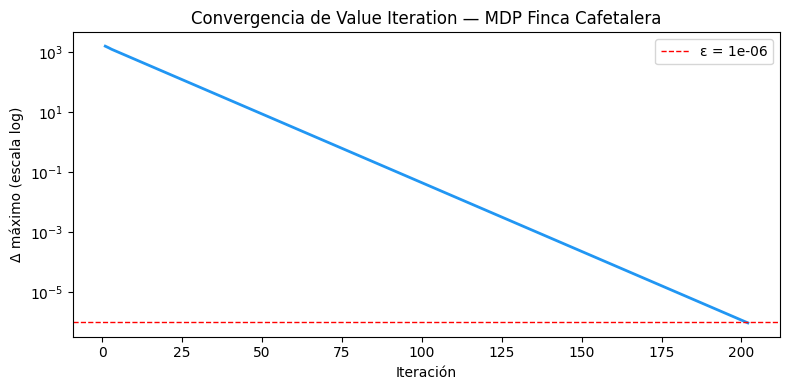

In [2]:
# Value Iteration instrumentado para capturar la curva de convergencia
estados  = todos_los_estados()
gamma    = 0.9
epsilon  = 1e-6

V       = {s: 0.0 for s in estados}
deltas  = []

while True:
    delta   = 0.0
    V_nuevo = {}
    for s in estados:
        mejor = None
        for a in ACCIONES:
            q = recompensa(s, a)
            for prob, s2 in transicion(s, a):
                q += gamma * prob * V.get(s2, 0.0)
            if mejor is None or q > mejor:
                mejor = q
        V_nuevo[s] = mejor
        delta = max(delta, abs(V_nuevo[s] - V[s]))
    V = V_nuevo
    deltas.append(delta)
    if delta < epsilon:
        break

policy = extract_policy(V)
print(f"Convergencia en {len(deltas)} iteraciones — delta final = {deltas[-1]:.2e}")

# Curva de convergencia
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(deltas)+1), deltas, color="#2196F3", linewidth=2)
ax.axhline(epsilon, color="red", linestyle="--", linewidth=1, label=f"ε = {epsilon}")
ax.set_xlabel("Iteración")
ax.set_ylabel("Δ máximo (escala log)")
ax.set_title("Convergencia de Value Iteration — MDP Finca Cafetalera")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Función de valor V(s) — los 36 estados

In [5]:
lbl_s  = {0: "Malo", 1: "Regular", 2: "Bueno"}
lbl_p  = {0: "Bajo", 1: "Medio",   2: "Alto"}
lbl_t  = {0: "Seca", 1: "Lluvia"}
lbl_r  = {0: "Sin roya", 1: "Con roya"}

filas = []
for s in estados:
    sal, pre, tem, rie = s
    filas.append({
        "Salud":      lbl_s[sal],
        "Presupuesto":lbl_p[pre],
        "Temporada":  lbl_t[tem],
        "Riesgo roya":lbl_r[rie],
        "V(s)":       round(V[s], 1),
        "Acción":     policy[s],
    })

df_v = pd.DataFrame(filas).sort_values("V(s)", ascending=False)
df_v.style.background_gradient(subset=["V(s)"], cmap="RdYlGn")

,Salud,Presupuesto,Temporada,Riesgo roya,V(s),Acción
32,Bueno,Alto,Seca,Sin roya,14893.600000,podar
28,Bueno,Medio,Seca,Sin roya,14893.600000,podar
30,Bueno,Medio,Lluvia,Sin roya,14885.600000,podar
34,Bueno,Alto,Lluvia,Sin roya,14885.600000,podar
35,Bueno,Alto,Lluvia,Con roya,14847.300000,fungicida
31,Bueno,Medio,Lluvia,Con roya,14847.300000,fungicida
29,Bueno,Medio,Seca,Con roya,14841.900000,fungicida
33,Bueno,Alto,Seca,Con roya,14841.900000,fungicida
24,Bueno,Bajo,Seca,Sin roya,14680.900000,podar
26,Bueno,Bajo,Lluvia,Sin roya,14656.900000,podar


## 3. Heatmap de política óptima — Salud × Riesgo (por temporada)

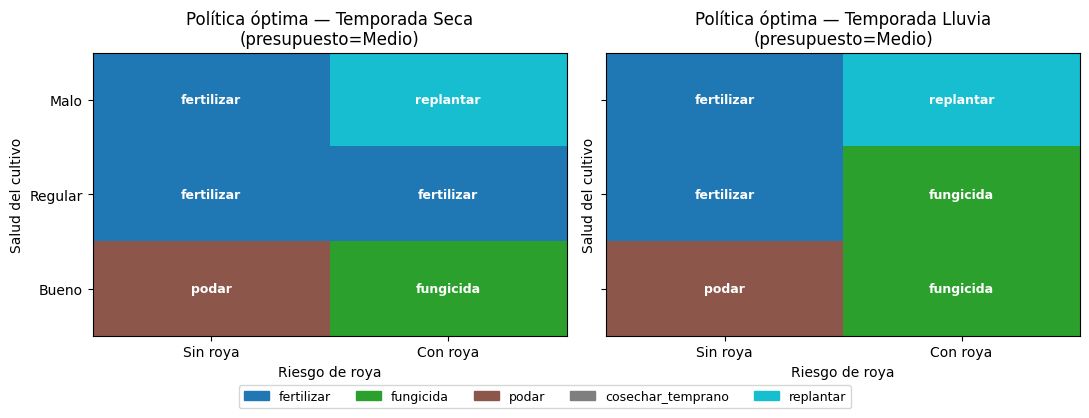

In [7]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

presupuesto_fijo = 1   # medio
acciones_idx = {a: i for i, a in enumerate(ACCIONES)}
cmap = plt.colormaps.get_cmap("tab10").resampled(len(ACCIONES))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for col, tem in enumerate([0, 1]):
    ax = axes[col]
    matriz_pol = np.zeros((3, 2), dtype=int)  # filas=salud, cols=riesgo
    for sal in range(3):
        for rie in range(2):
            s = (sal, presupuesto_fijo, tem, rie)
            matriz_pol[sal, rie] = acciones_idx[policy[s]]

    im = ax.imshow(matriz_pol, cmap=cmap, vmin=0, vmax=len(ACCIONES)-1, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Sin roya", "Con roya"])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["Malo", "Regular", "Bueno"])
    ax.set_xlabel("Riesgo de roya")
    ax.set_ylabel("Salud del cultivo")
    ax.set_title(f"Política óptima — Temporada {'Lluvia' if tem else 'Seca'}\n(presupuesto=Medio)")

    for sal in range(3):
        for rie in range(2):
            accion = policy[(sal, presupuesto_fijo, tem, rie)]
            ax.text(rie, sal, accion, ha="center", va="center", fontsize=9, color="white",
                    fontweight="bold")

legend_patches = [mpatches.Patch(color=cmap(i), label=a) for i, a in enumerate(ACCIONES)]
fig.legend(handles=legend_patches, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 4. Recomendaciones en lenguaje natural para escenarios reales

In [8]:
escenarios_reales = [
    ((0, 0, 1, 1), "Cultivo muy afectado, sin presupuesto, época de lluvia con roya"),
    ((1, 1, 1, 1), "Cultivo regular, presupuesto medio, lluvia con roya"),
    ((2, 2, 0, 0), "Cultivo bueno, presupuesto alto, época seca sin roya"),
    ((0, 2, 1, 0), "Cultivo malo, buen presupuesto, lluvia sin roya"),
    ((2, 1, 0, 1), "Cultivo bueno, presupuesto medio, seco con roya"),
]

for estado, descripcion in escenarios_reales:
    rec = get_action_recommendation(estado, policy)
    print("=" * 65)
    print(f"Escenario: {descripcion}")
    print(f"  Estado:  {rec['estado']}")
    print(f"  ► Acción óptima: {rec['accion'].upper()}")
    print(f"  ► Justificación: {rec['justificacion']}")
    print(f"  ► V(s) = {V[estado]:,.1f} Q/ha")

Escenario: Cultivo muy afectado, sin presupuesto, época de lluvia con roya
  Estado:  {'Salud del cultivo': 'Malo', 'Presupuesto': 'Bajo', 'Temporada': 'Temporada de lluvia', 'Riesgo de roya': 'Alto'}
  ► Acción óptima: REPLANTAR
  ► Justificación: Replantar con variedades resistentes (ej. Catimor) elimina focos de roya y reinicia el ciclo productivo. Es costoso a corto plazo pero maximiza el rendimiento a largo plazo.
  ► V(s) = 8,711.9 Q/ha
Escenario: Cultivo regular, presupuesto medio, lluvia con roya
  Estado:  {'Salud del cultivo': 'Regular', 'Presupuesto': 'Medio', 'Temporada': 'Temporada de lluvia', 'Riesgo de roya': 'Alto'}
  ► Acción óptima: FUNGICIDA
  ► Justificación: Aplicar fungicida es la acción más efectiva contra la roya del café. Reduce el riesgo de infección en ~85% y protege el rendimiento de la cosecha.
  ► V(s) = 12,604.2 Q/ha
Escenario: Cultivo bueno, presupuesto alto, época seca sin roya
  Estado:  {'Salud del cultivo': 'Bueno', 'Presupuesto': 'Alto', 'Temporada'